<a href="https://colab.research.google.com/github/eugeniohdez05/Laboratorio-de-aprendizaje-estadistico/blob/main/Tarea_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

1. Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).

**R=** $$\text{Definimos la función: } \\f(\alpha)=Var(\alpha X + (1 - \alpha)Y) \\ \text{Expandimos la varianza:}\\ f(\alpha) = Var(\alpha X) + Var((1 - \alpha)Y) + 2Cov(\alpha X, (1 - \alpha)Y)\\ f(\alpha) = \alpha^2\sigma_X^2 + (1 - \alpha)^2\sigma_Y^2 + 2\alpha(1 - \alpha)\sigma_{XY} \\ \text{Derivamos con respecto a } \alpha: \\  f'(\alpha) = 2\alpha\sigma_X^2 - 2(1 - \alpha)\sigma_Y^2 + 2(1 - 2\alpha)\sigma_{XY}\\ \text{Igualamos a cero:} \\ 0 = 2\alpha\sigma_X^2 - 2\sigma_Y^2 + 2\alpha\sigma_Y^2 + 2\sigma_{XY} - 4\alpha\sigma_{XY} \\ \text{Despejamos } \alpha: \\ \alpha(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}) = \sigma_Y^2 - \sigma_{XY}$$

2. We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

(A)What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.

**R=** $$ \text{Como hay }n \text{ observaciones y cada una tiene probabilidad } \frac{1}{n} \text{ de ser elegida, la probabilidad de no elegir la j-ésima es: }\\ 1-\frac{1}{n}$$

(B) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?

**R=** $$\text{Dado que el muestreo es con reemplazo, las extracciones son independientes; por lo tanto, la probabilidad sigue siendo: }\\ 1-\frac{1}{n} $$

(C) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.

**R=** Para que no esté en la muestra final, no debe ser elegida en ninguna de las $n$ extracciones independientes.

Esto es el producto de las probabilidades individuales: $(1 - 1/n)$, lo que resulta en $(1 - 1/n)^n$.

(D) When n = 5, what is the probability that the jth observation is
in the bootstrap sample?

$P(\text{esté}) = 1 - P(\text{no esté}) = 1 - (1 - 1/5)^5 = 1 - (0.8)^5 = 1 - 0.32768 = 0.67232$.

(E) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?

$P(\text{esté}) = 1 - (1 - 1/100)^{100} = 1 - (0.99)^{100} \approx 1 - 0.36603 \approx 0.63397$

(F) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?

$P(\text{esté}) = 1 - (1 - 1/10,000)^{10,000} \approx 1 - 0.36786 \approx 0.63214$



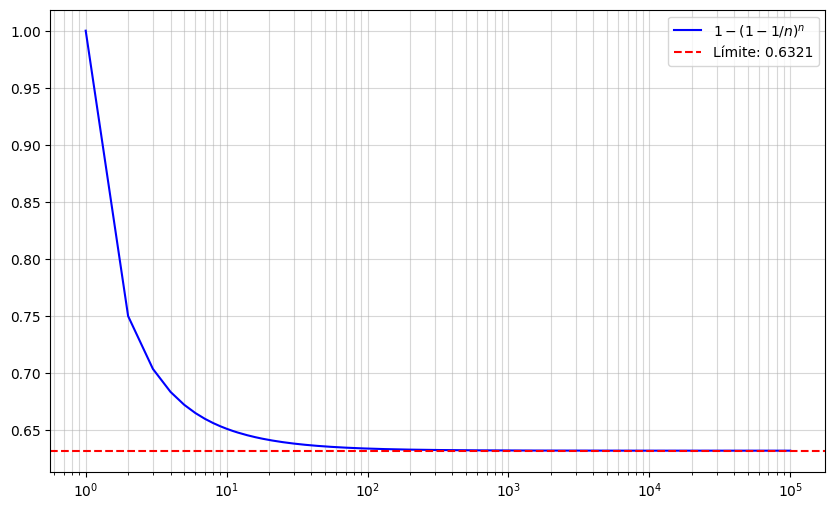

In [5]:
#(G) Create a plot that displays, for each integer value of n from 1 to 100, 000, the probability that the jth observation is in the bootstrap sample. Comment on what you observe.
n = np.arange(1, 100001)

# Calcular la probabilidad: 1 - (1 - 1/n)^n
probabilidad = 1 - (1 - 1/n)**n

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(n, probabilidad,label=r'$1 - (1 - 1/n)^n$', color='blue')

# Añadir la línea del límite asintótico (1 - 1/e)
limite = 1 - 1/np.exp(1)
plt.axhline(y=limite, color='red', linestyle='--', label=f'Límite: {limite:.4f}')

# Configuración de etiquetas y escalas
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()



Observaciones: Conforme el valor aumenta la línea va tendiendo al límite

Aplicados

(a) Fit a logistic regression model that uses income and balance to

predict default.

(b) Using the validation set approach, estimate the test error of this

model. In order to do this, you must perform the following steps:

i. Split the sample set into a training set and a validation set.

ii. Fit a multiple logistic regression model using only the training observations.

iii. Obtain a prediction of default status for each individual in

the validation set by computing the posterior probability of

default for that individual, and classifying the individual to

the default category if the posterior probability is greater

than 0.5.

iv. Compute the validation set error, which is the fraction of

the observations in the validation set that are misclassified.

(c) Repeat the process in (b) three times, using three different splits

of the observations into a training set and a validation set. Comment on the results obtained.